# 01. Prediction-market layer: from contracts to theme indices

This notebook summarises the first half of the MFE 230GB project: how thousands of Polymarket and Kalshi contracts become **continuous theme indices**, and then the signals used by the two strategies.

Read it from top to bottom. Each section first gives the idea, then the numbers from the files produced by the pipeline (`data/processed/`, `results/`). Nothing is recomputed here, apart from a few quick illustrations.

| Section | Content |
|---|---|
| 1 | Source data and the 16:00 London snapshot |
| 2 | Contract classification (rules, no LLM) |
| 3 | Inclusion rules and the coverage table (the gate) |
| 4 | Common units: partitions, hazard rates, normalisation |
| 5 | Theme indices and checks on known episodes |
| 6 | Strategy B's geopolitical index: escalation and shocks |
| 7 | Weekend changes (FX market closed) |
| 8 | Summary of decisions |

**Reproduce**: `.venv/Scripts/python.exe run_all.py --stage pm`. The decisions cited (D1, D2, ...) are detailed in `DECISIONS.md`.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
pd.set_option("display.width", 160); pd.set_option("display.max_colwidth", 90)
P = "data/processed/"
print("working directory:", os.getcwd())

working directory: D:\haas-mfe-g9-cg\Kairos_Project\Perso\Piero&Romain\GB\230gb-pm-fx


## 1. Source data and the 16:00 London snapshot

**Source.** The Probalytics archive of the Kairos project, read-only: market metadata and the tape of every trade, on Polymarket and Kalshi.
- The frozen archive ends on 21 July 2026.
- A "live" tape with the same schema extends it to 24 September 2026 (D9). It is nearly empty afterwards.

**Two traps found in the data.**
- The category and tag fields are empty everywhere, so the classification has to be built from scratch (section 2).
- The `amount_usd` column contains negative values, so volume is recomputed as |price × size| (D10).

**Snapshot.** Prediction-market signals are measured at **16:00 London** every day.
- A contract's value on day t is its **last trade strictly before 16:00 London** on t.
- The time-zone conversion is done date by date: US and EU daylight-saving changes do not fall in the same weeks.
- A contract with no trade in the previous 6 hours is marked *stale* that day.
- FX prices are Bloomberg closes, observed after the snapshot for the G10 and Latin America: a signal of day t trades at the close of t (D28).

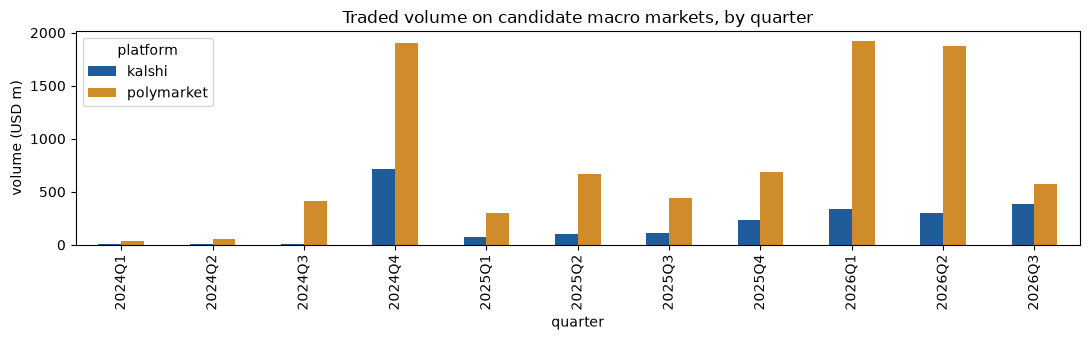

            markets  market_days  volume_bn
platform                                   
kalshi        50281       906321       2.28
polymarket    29922       967232       8.88


In [2]:
daily = pd.read_parquet(P + "pm_daily.parquet")
daily["quarter"] = pd.to_datetime(daily["snap_date"]).dt.to_period("Q")
vol = daily.groupby(["quarter", "platform"])["volume_usd"].sum().unstack() / 1e6
ax = vol.plot(kind="bar", figsize=(11, 3.5), color=["#1f5c99", "#d08c2a"])
ax.set_ylabel("volume (USD m)"); ax.set_title("Traded volume on candidate macro markets, by quarter")
plt.tight_layout(); plt.show()
print(daily.groupby("platform").agg(markets=("platform_id", "nunique"), market_days=("snap_date", "size"),
                                     volume_bn=("volume_usd", lambda s: round(s.sum() / 1e9, 2))))

Polymarket is thin until mid-2024. The peaks match the 2024 US election and the 2026 conflict with Iran. Kalshi has non-US central-bank decisions (`KXCBDECISION*`) only from November 2025.

**Look-ahead check.** For every row of the panel, the last trade used must fall in the window (16:00 London on t-1, 16:00 London on t). The test also checks a US/EU daylight-saving gap day (mid-March 2024).

In [3]:
import duckdb
con = duckdb.connect(); con.execute("SET TimeZone='UTC'")
bad = con.execute(f"""SELECT count(*) FROM read_parquet('{P}pm_daily.parquet')
  WHERE last_ts >= timezone('Europe/London', CAST(snap_date AS TIMESTAMP) + INTERVAL 16 HOUR)
     OR last_ts <  timezone('Europe/London', CAST(snap_date - 1 AS TIMESTAMP) + INTERVAL 16 HOUR)""").fetchone()[0]
print("rows violating the snapshot window:", bad)
for d in ["2024-03-15", "2024-04-15", "2024-10-30"]:
    h = con.execute(f"SELECT hour(timezone('Europe/London', TIMESTAMP '{d} 16:00:00'))").fetchone()[0]
    print(d, "16:00 London =", h, ":00 UTC")

rows violating the snapshot window: 0
2024-03-15 16:00 London = 16 :00 UTC
2024-04-15 16:00 London = 15 :00 UTC
2024-10-30 16:00 London = 16 :00 UTC


## 2. Contract classification (rules, no LLM)

The spec planned an LLM-assisted classification. It is replaced by **deterministic rules** (D1): reproducible, free, with no API dependency. Every market gets four attributes.

| Attribute | Source |
|---|---|
| **Theme**: MONETARY, INFLATION, FISCAL_POLITICAL, TRADE_TARIFFS, GEOPOLITICS or OTHER | Kalshi series table, then text rules inspired by `classifier_v2` (kairos-main) |
| **Zone**: US, EA, JP, UK, ..., EM ISO code, GLOBAL | Geographic resolver `geo_registry` (Arb project): countries, central bankers, leaders, institutions |
| **Direction**: +1 if a higher "Yes" probability raises the theme index, -1 otherwise, 0 if ambiguous | Regex per theme; table `party_fiscal_stance.csv` for elections |
| **Partition**: bucket of a mutually exclusive set (Fed decision, CPI brackets, tariff rates) | Bucket value in a common unit (bp, pp, %) |

Sign conventions (spec 4.4): a higher index means more hawkish policy, higher inflation, more fiscal expansion or risk, more trade restriction, more escalation.

In [4]:
lab = pd.read_parquet(P + "contracts_classified.parquet")
lab["usable"] = (lab["direction"] != 0) | lab["partition"]
print(lab.groupby("theme").agg(markets=("platform_id", "size"), events=("event_key", "nunique"),
                                usable=("usable", "sum")).sort_values("markets", ascending=False))

                  markets  events  usable
theme                                    
OTHER               50499   10162       0
FISCAL_POLITICAL    16902    4076    1616
GEOPOLITICS          5301    1629    3504
INFLATION            3860     559    3170
MONETARY             2818     541    2211
TRADE_TARIFFS         823     275     775


In [5]:
ex = lab[lab.theme != "OTHER"].groupby("theme").sample(4, random_state=3)
ex["zones"] = ex["zones"].apply(lambda z: "|".join(z))
ex[["theme", "zones", "direction", "partition", "bucket_value", "title", "direction_rule"]]

,theme,zones,direction,partition,bucket_value,title,direction_rule
61253,FISCAL_POLITICAL,EA,0,False,NaN,New Netherlands election announced before Summer Recess?,fiscal:none
72179,FISCAL_POLITICAL,US,0,False,NaN,Will Trump make 4 trips to Mar-a-Lago as President in May 2025?,fiscal:none
73010,FISCAL_POLITICAL,EA,0,False,NaN,Will the Volt Netherlands win the fourth most seats in the 2025 Netherlands parliament...,fiscal:none
43785,FISCAL_POLITICAL,US,0,False,NaN,Who will win 2025 California Statewide Special Election?,fiscal:none
17606,GEOPOLITICS,GLOBAL,0,False,NaN,Game 1: Both Teams Slay a Dragon?,geo:none
66624,GEOPOLITICS,GLOBAL,0,False,NaN,"Will there be more than 50 transit calls through the Strait of Hormuz from Jun 29, 202...",geo:none
53662,GEOPOLITICS,GLOBAL|US,0,False,NaN,US x Russia military clash by December 31?,geo:none
23831,GEOPOLITICS,GLOBAL,-1,False,NaN,Israel x Hezbollah Ceasefire in 2024?,geo:deescalate:ceasefire
6882,INFLATION,US,0,True,0.30,Will monthly inflation increase by 0.3% in August?,partition-bucket
38527,INFLATION,UK,0,True,2.55,Will UK annual inflation be 2.7% or less in September?,partition-bucket


**Validation.** A random sample of 200 events, stratified by theme, is ready to be labelled by hand, blind: `ai_log/classification/validation_sheet_1.csv` to `_4.csv` (50 rows each; guide in `LABELLING_GUIDE.md`). Accuracy per field (theme, zone, direction) is then computed with `python -m src.pm.validation score`. The rules are frozen: the score is reported as it comes out.

## 3. Inclusion rules and the coverage table (the gate)

A contract enters an index on day t only if all five conditions hold (spec 4.1):
1. it exists at t;
2. its volume over the previous 7 days exceeds **USD 50,000** (robustness grid: 10k and 250k);
3. its time to resolution is between 3 and 365 days;
4. its probability is between 0.03 and 0.97;
5. it has a defined direction, or it is a partition.

Everything uses information available at t: past volume, closing date fixed at creation.

**Coverage table** (spec 4.3): share of weekdays with at least one eligible contract, by cell (zone × theme). A cell is kept only if this share reaches **60% in 2024-2025**.

In [6]:
cells = pd.read_csv("results/coverage_cells.csv")
cells.head(12)[["zone", "theme", "share_train", "share_test", "n_contracts", "volume_usd_m", "keep"]]

,zone,theme,share_train,share_test,n_contracts,volume_usd_m,keep
0,US,MONETARY,0.939,1.000,110,561.43,True
1,GLOBAL,GEOPOLITICS,0.767,1.000,649,555.53,True
2,US,FISCAL_POLITICAL,0.685,1.000,265,1187.36,True
3,US,GEOPOLITICS,0.526,1.000,298,249.51,False
4,CN,GEOPOLITICS,0.331,1.000,9,19.23,False
5,US,TRADE_TARIFFS,0.308,0.241,59,8.43,False
6,US,INFLATION,0.250,0.277,64,9.01,False
7,KR,FISCAL_POLITICAL,0.226,0.000,17,25.71,False
8,CN,TRADE_TARIFFS,0.199,0.042,14,2.45,False
9,EA,FISCAL_POLITICAL,0.076,0.178,11,2.36,False


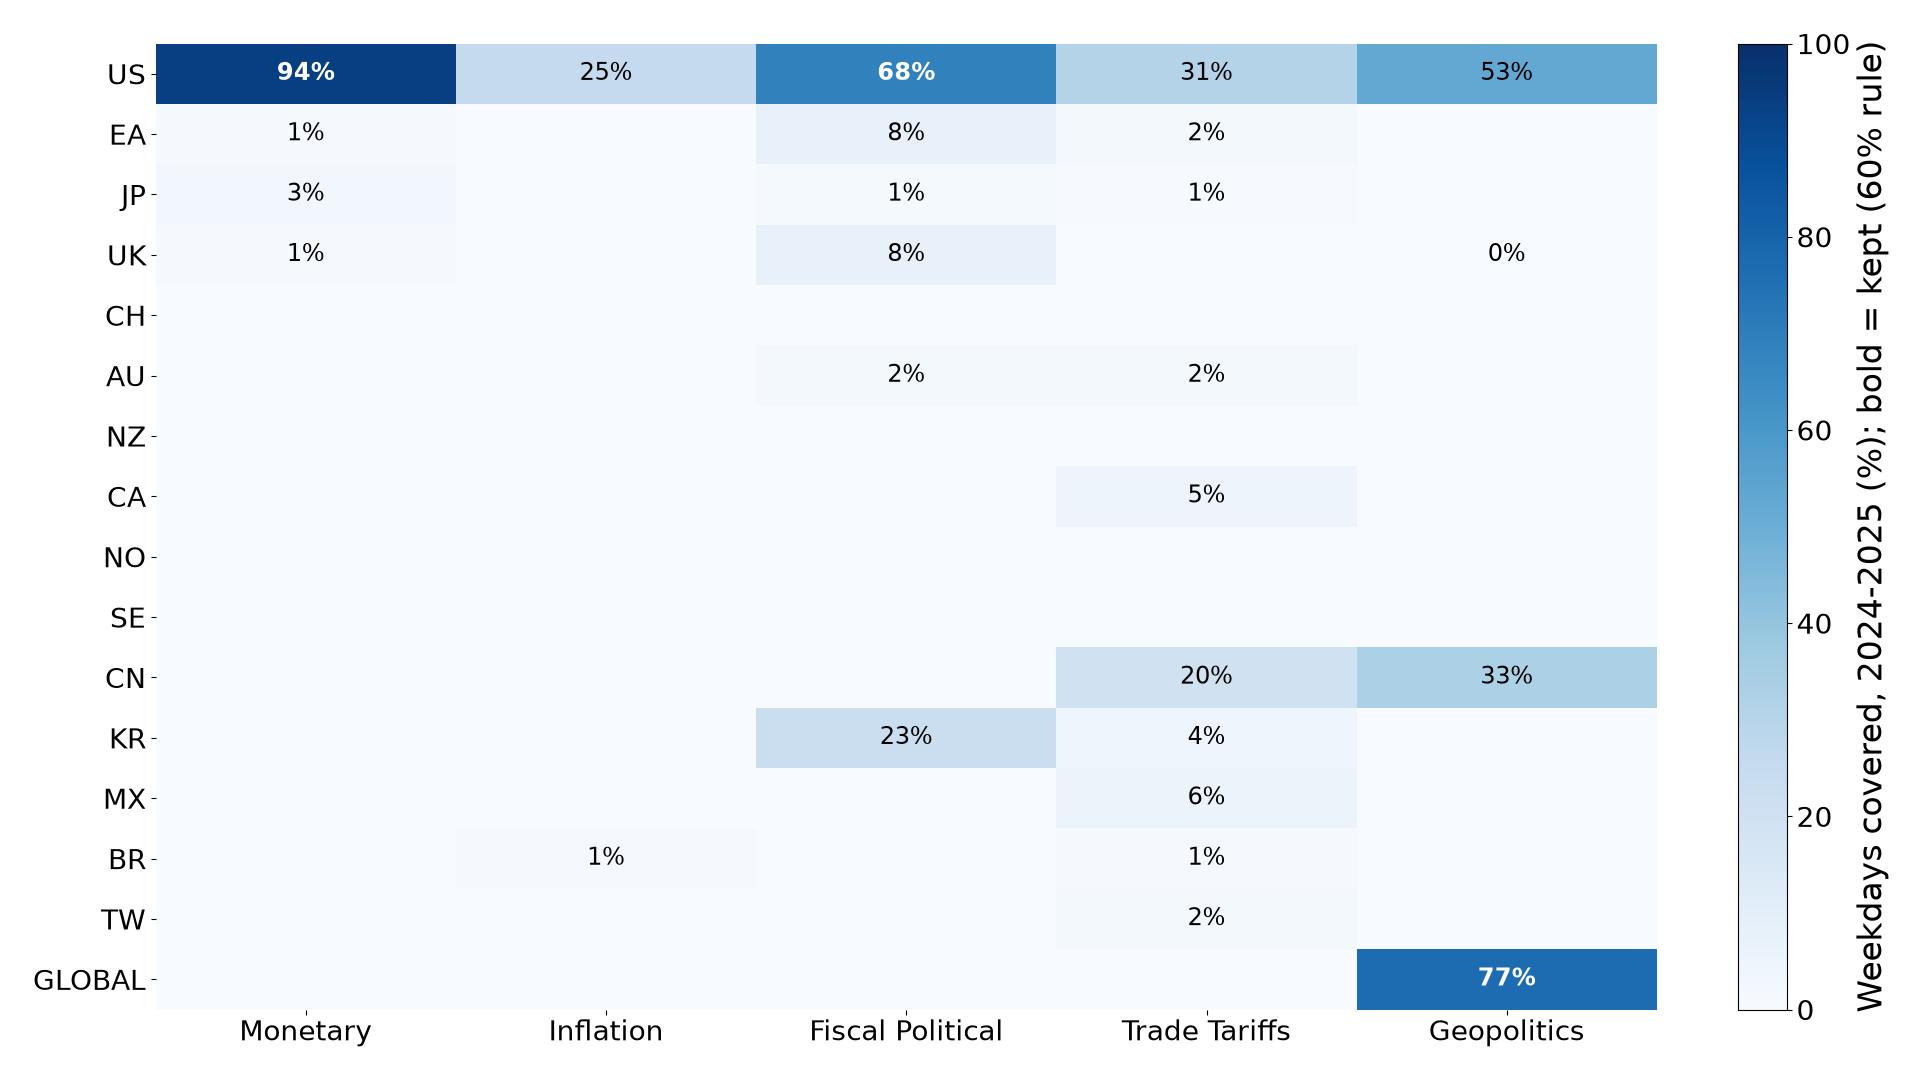

In [7]:
display(Image("results/figures/slides/slide_coverage_heatmap.png", width=800))

**Key result (D13).** Only three cells pass: US MONETARY, GLOBAL GEOPOLITICS and US FISCAL_POLITICAL. Non-US G10 cells are below 10% over the training period.

The spec's country-relative signals are therefore not feasible for most G10 pairs. Hence the three variants declared in advance for Strategy A (D14), covered in notebook 02.

## 4. Common units: partitions, hazard rates, normalisation

**Partitions** (spec 4.5). For a Fed decision, each bucket (cut 50, cut 25, hold, hike) is a separate market. Adding their changes would make no sense. The contract value is therefore the **expected** rate change: sum of probabilities × bucket value, renormalised, in bp.

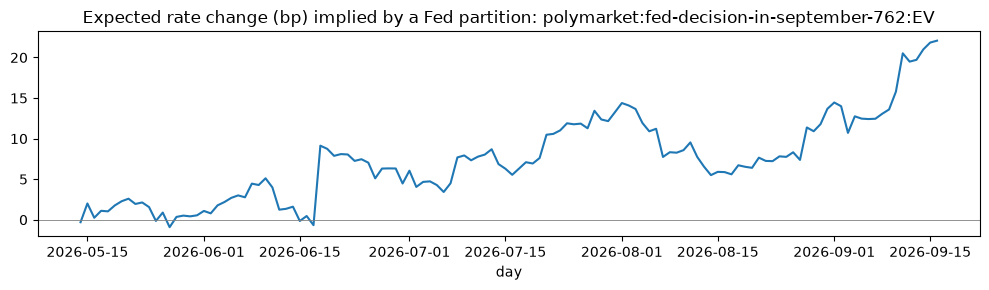

In [8]:
cd = pd.read_parquet(P + "contract_days.parquet", columns=["contract_id", "theme", "zone", "unit", "day", "value", "eligible"])
ev = cd[cd.contract_id.str.contains("fed-decision-in-september-762|fed-decision-in-september:EV", regex=True) & (cd.unit == "bp")]
k = ev.contract_id.iloc[0] if len(ev) else cd[(cd.unit == "bp") & (cd.zone == "US")].contract_id.value_counts().index[0]
s = cd[cd.contract_id == k].drop_duplicates("day").set_index("day")["value"]
ax = s.plot(figsize=(10, 3), title=f"Expected rate change (bp) implied by a Fed partition: {k}")
ax.axhline(0, color="grey", lw=0.6); plt.tight_layout(); plt.show()

**Deadline markets and hazard rates (D18).** Many markets ask "will X happen before a given date?" ("Fed rate cut by May 1", "US strikes Iran by..."). If nothing happens, their probability falls mechanically as the deadline approaches. That fall would create a spurious trend in the index.

The value used is therefore the **implied hazard rate**: λ = -ln(1 - p) / τ, with τ the time left to the deadline, in years, floored at 3 days. A constant hazard no longer produces a drift. 2,974 of the 9,103 contracts in the panel are valued this way (`results/RESULTS.md`, section 1).

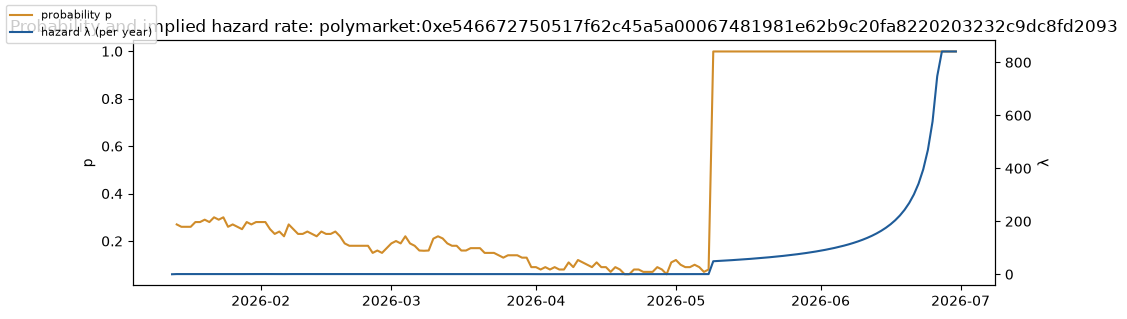

In [9]:
hz = pd.read_parquet(P + "contract_days.parquet", columns=["contract_id", "unit", "day", "px", "value", "vol1d"])
hz = hz[hz.unit == "hazard"].drop_duplicates(["contract_id", "day"])
top = hz.groupby("contract_id")["vol1d"].sum().sort_values().index[-1]
x = hz[hz.contract_id == top].set_index("day").sort_index()
fig, ax1 = plt.subplots(figsize=(10, 3.2))
ax1.plot(x.index, x["px"], color="#d08c2a", label="probability p"); ax1.set_ylabel("p")
ax2 = ax1.twinx(); ax2.plot(x.index, x["value"], color="#1f5c99", label="hazard λ (per year)"); ax2.set_ylabel("λ")
ax1.set_title(f"Probability and implied hazard rate: {top}"); fig.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

**Normalisation (D11, D19).**
- A contract's daily change is measured from its last non-stale snapshot (at most 7 days earlier), then divided by √g when it spans g days.
- It is then standardised by the contract's **own** EWMA volatility (span 60), estimated on past changes only.
- It is winsorised at ±5 standard deviations.
- Finally it is aggregated within the cell, weighted by the volume of the last 7 days (variant: equal weights).

The cell's index is the cumulative sum of these aggregated changes: a continuous series despite the turnover of contracts, like a rolled future.

## 5. Theme indices and checks on known episodes

These checks are used to find bugs, never to tune parameters.

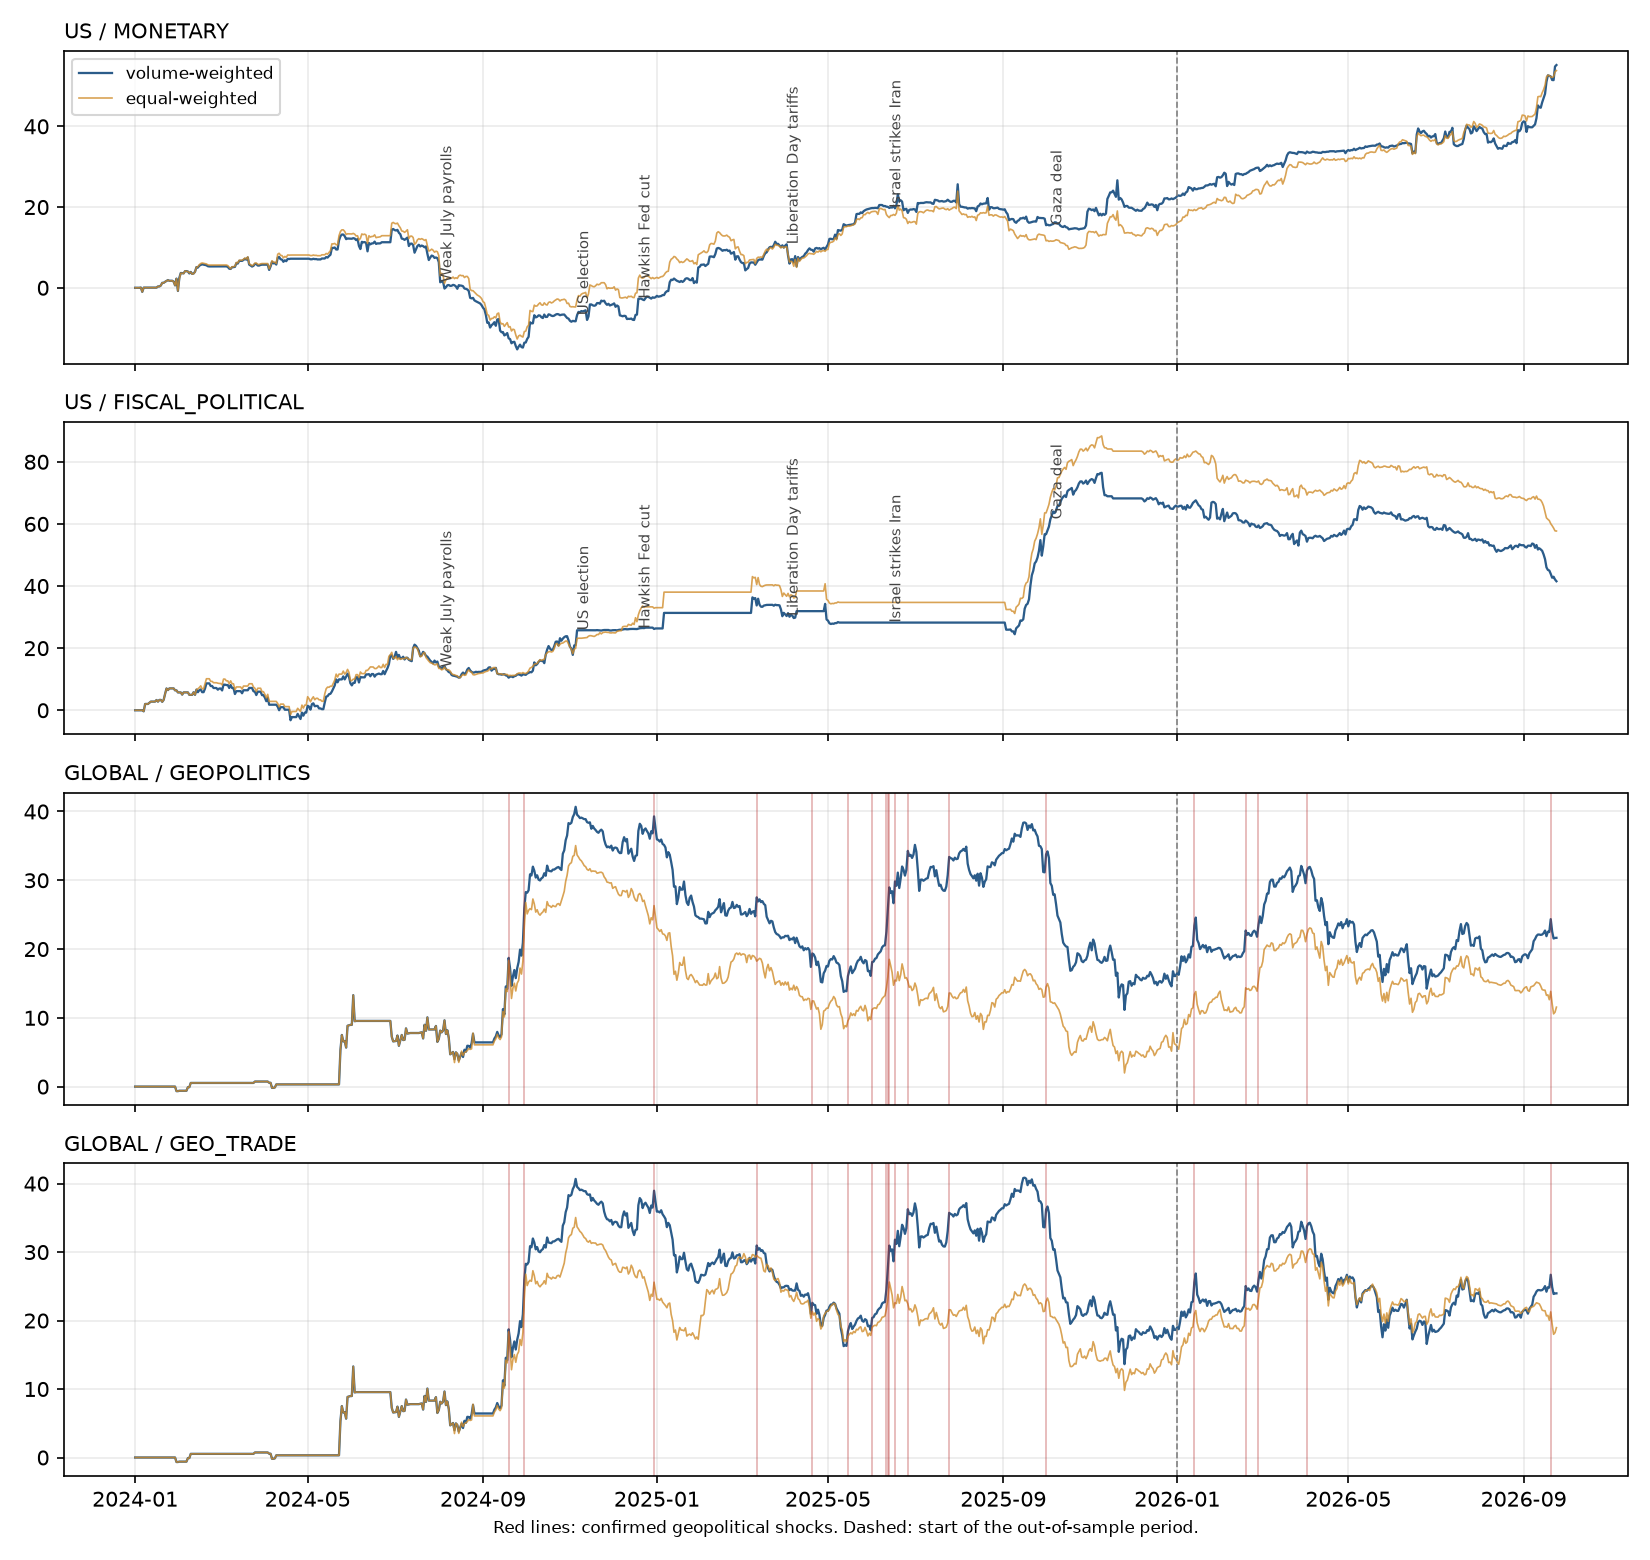

In [10]:
display(Image("results/figures/theme_indices.png", width=900))

In [11]:
idx = pd.read_parquet(P + "theme_index.parquet")
for z, t in [("US", "MONETARY"), ("US", "FISCAL_POLITICAL"), ("GLOBAL", "GEOPOLITICS")]:
    s = idx[(idx.zone == z) & (idx.theme == t)].set_index("day")["d_vw"]
    top = s.abs().sort_values(ascending=False).head(6).index
    print(f"\n{z}/{t}: largest daily moves (standard deviations)")
    print(s.loc[sorted(top)].round(2).to_string())


US/MONETARY: largest daily moves (standard deviations)
day
2024-08-02   -5.00
2025-07-31    4.51
2025-08-01   -4.92
2025-11-20    4.10
2025-11-21   -4.80
2026-06-18    4.55

US/FISCAL_POLITICAL: largest daily moves (standard deviations)
day
2024-11-06    4.75
2025-01-06    5.00
2025-03-09    5.00
2025-04-30   -5.00
2025-09-28   -5.00
2026-01-25    4.79

GLOBAL/GEOPOLITICS: largest daily moves (standard deviations)
day
2024-05-24    5.00
2024-06-02    4.32
2024-06-03   -3.79
2024-09-17    4.07
2024-09-19    4.54
2024-09-30    5.00


Examples:
- **US MONETARY**: a large dovish move on 2 August 2024 (weak payrolls) and on 1 August 2025 (revisions), a hawkish move on 19 December 2024 (the "hawkish cut");
- **US FISCAL_POLITICAL**: a rise on the day of the 2024 election;
- **GLOBAL GEOPOLITICS**: shocks from 12 to 17 June 2025 (Israel-Iran), a fall in early October 2025 (Gaza deal).

**Residual drift.** The next table compares the average daily change of the indices with the hazard rate (D18, primary version) and without it (probabilities, the basis of the D12 variant).

In [12]:
rows = []
for f, lab_ in [("theme_index", "hazard (D18)"), ("theme_index_prob", "probabilities (D12 variant)")]:
    i = pd.read_parquet(P + f + ".parquet")
    for z, t in [("US", "MONETARY"), ("US", "FISCAL_POLITICAL"), ("GLOBAL", "GEOPOLITICS")]:
        a = i[(i.zone == z) & (i.theme == t) & (i.n_contracts > 0)]["d_vw"]
        rows.append({"version": lab_, "cell": f"{z}/{t}", "mean daily change": round(a.mean(), 3),
                     "t-stat": round(a.mean() / a.std() * len(a) ** 0.5, 1)})
pd.DataFrame(rows)

,version,cell,mean daily change,t-stat
0,hazard (D18),US/MONETARY,0.059,2.1
1,hazard (D18),US/FISCAL_POLITICAL,0.055,1.4
2,hazard (D18),GLOBAL/GEOPOLITICS,0.027,0.7
3,probabilities (D12 variant),US/MONETARY,0.079,2.9
4,probabilities (D12 variant),US/FISCAL_POLITICAL,0.027,0.8
5,probabilities (D12 variant),GLOBAL/GEOPOLITICS,0.032,1.0


The hazard transform clearly reduces the drift of US MONETARY. What remains comes mostly from "number of cuts in the year" partitions, whose expected value also falls as time passes without a cut. Keep this in mind: the D12 variant (causal demeaning) neutralises it and serves as a check.

## 6. Strategy B's geopolitical index: escalation and shocks

B's index aggregates GEOPOLITICS contracts (zone GLOBAL) and US tariff contracts, oriented towards escalation. Two components come out of it.

- **Escalation (D16)**: EWMA (half-life 20 days) of the daily changes, then an expanding z-score after a 60-trading-day burn-in. The version first written (z-score of the index *level*) was misspecified: the cumulative index is a random walk, and its z-score measures the drift since the start of the sample, not a risk level.
- **Shock**: a daily change above k = 2 standard deviations (causal σ). It is **confirmed** only if all of the following hold:
  - the move was already visible 4 hours before the snapshot, or it persists at the next snapshot;
  - volume exceeds the threshold;
  - both platforms move in the same direction when both cover the event.

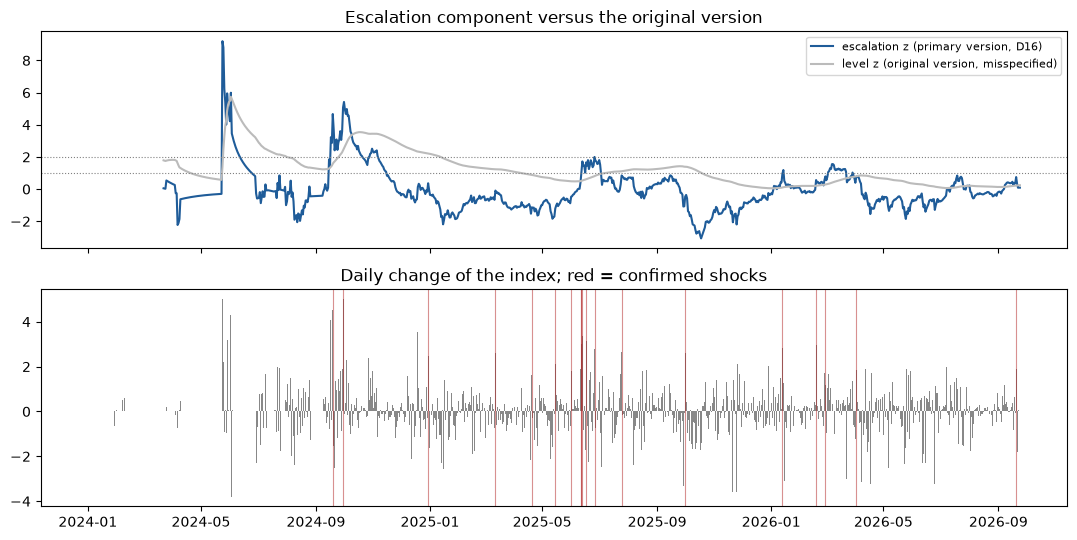

month-ends with z >= 1: escalation 0.12 | original version 0.45
raw shocks: 23 | confirmed: 19
               d  d_early  n_contracts  volume_usd
day                                               
2024-09-19  4.54     1.62          1.0    69033.70
2024-09-30  5.00     5.00          1.0    80637.04
2024-12-30  2.46     2.11          3.0   143626.63
2025-03-12  2.63     2.26          8.0  1930670.67
2025-04-20  1.62     1.60         13.0   650655.57
2025-05-15  2.13     1.45         14.0   402897.42
2025-06-01  1.81     1.66         12.0   401036.89
2025-06-11  1.88     1.55         11.0   487426.96
2025-06-12  3.03     3.10         10.0   855561.37
2025-06-13  3.34     3.39          8.0   953015.69
2025-06-17  3.16     3.02         17.0  2270836.02
2025-06-26  2.77     2.98         17.0  1413087.61
2025-07-25  2.66     1.73          6.0   784453.76
2025-10-01  2.61     2.71         13.0   450738.41
2026-01-13  2.81     1.71         31.0  3182144.35
2026-02-18  2.94     1.95         24.0

In [13]:
g = pd.read_parquet(P + "geo_signals.parquet").set_index("day")
fig, ax = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
ax[0].plot(g.index, g["escalation_z"], color="#1f5c99", label="escalation z (primary version, D16)")
ax[0].plot(g.index, g["level_z_spec_misspecified"], color="#bbbbbb", label="level z (original version, misspecified)")
for v in (1, 2): ax[0].axhline(v, color="grey", ls=":", lw=0.8)
ax[0].legend(fontsize=8); ax[0].set_title("Escalation component versus the original version")
ax[1].bar(g.index, g["d"], color="#888888", width=1.0)
for t in g.index[g["confirmed"]]: ax[1].axvline(t, color="#b22222", alpha=0.5, lw=0.8)
ax[1].set_title("Daily change of the index; red = confirmed shocks")
plt.tight_layout(); plt.show()
me = g["escalation_z"].resample("ME").last(); ml = g["level_z_spec_misspecified"].resample("ME").last()
print("month-ends with z >= 1: escalation", round((me >= 1).mean(), 2), "| original version", round((ml >= 1).mean(), 2))
print("raw shocks:", int(g["shock_raw"].sum()), "| confirmed:", int(g["confirmed"].sum()))
print(g.loc[g.confirmed, ["d", "d_early", "n_contracts", "volume_usd"]].round(2))

## 7. Weekend changes (FX market closed)

The FX market closes from Friday 17:00 to Sunday 17:00 New York, while prediction markets keep trading. The change of each cell over this window is computed for **every weekend** since 2024, with no selection. It is the signal of Strategy A's weekend gap test, which compares it with the FX reopening gap. It is the cleanest identification in the project: information arrives while FX cannot react.

In [14]:
wk = pd.read_parquet(P + "weekend_changes.parquet")
for z, t in [("GLOBAL", "GEOPOLITICS"), ("US", "FISCAL_POLITICAL"), ("US", "MONETARY")]:
    x = wk[(wk.zone == z) & (wk.theme == t)].set_index("friday")["d_vw"]
    print(f"{z}/{t}: {len(x)} weekends; largest:", x.abs().sort_values(ascending=False).head(4).index.date.tolist())

GLOBAL/GEOPOLITICS: 118 weekends; largest: [datetime.date(2026, 2, 27), datetime.date(2024, 10, 4), datetime.date(2025, 6, 20), datetime.date(2024, 5, 24)]
US/FISCAL_POLITICAL: 107 weekends; largest: [datetime.date(2025, 9, 19), datetime.date(2026, 1, 23), datetime.date(2024, 7, 12), datetime.date(2024, 11, 1)]
US/MONETARY: 136 weekends; largest: [datetime.date(2024, 9, 6), datetime.date(2026, 7, 24), datetime.date(2026, 6, 19), datetime.date(2026, 2, 6)]


Reading:
- **GLOBAL GEOPOLITICS**: the largest weekend is that of 27 February 2026 (+4.6 standard deviations), at the start of the war with Iran. The weekend of 20 June 2025, that of the US strikes on Fordow, ranks 3rd of 118 (+4.0).
- **US FISCAL_POLITICAL**: the weekend of 12 July 2024, that of the assassination attempt on Trump, gives +2.9.

Weekend changes are in the same units as daily changes: hazard rates for deadline markets (D18), standardised by the same volatility.

## 8. Summary of decisions

| Decision | Subject |
|---|---|
| D1 | Rule-based classification (no LLM) |
| D2 | Strategy A: theory-signed rule, no estimation; regression-gated rule as a variant |
| D9, D10 | Sample ends on 2026-09-24; volume = \|price × size\| |
| D11, D19 | Change since the last fresh snapshot, scaled by √g |
| D12 → D18 | Drift of deadline markets: hazard rate (primary), causal demeaning (variant) |
| D13 | Coverage: only US MONETARY, US FISCAL, GLOBAL GEOPOLITICS pass |
| D14, D17 | Three variants of A; A does not use the contracts of B's index |
| D15 | Time-varying fiscal regime (10-year yield / currency correlation) |
| D16 | Stationary escalation component for B |
| D20, D21 | Annotated spec; data exported for the HTML page |
| D22 | Preliminary results on free data (kept in `results/preliminary_free/`) |
| D23 to D27 | B's universe (IRR), pre-registered weekend test and lead-lag, decomposition of A, fiscal regime |
| D28, D29 | Delivered market data (Bloomberg, WRDS, official yields) and timing; diagnostic of B's gap |
| D30, D31 | A posteriori additions after the definitive results, then the final freeze |

The rest (strategies, backtest, tests, definitive results) is in notebook **02**.